Con riferimento al data set dell’esercitazione su clustering, eseguire una classificazione
binaria sulla feature death, una classificazione multiclasse sulla feature dzgroup ed una
regressione sulla feature aps.

In [54]:
# DEATH
import pandas as pd
df = pd.read_csv("C:\\Users\\pcdis\\Desktop\\Universita\\BigData2\\Condiviso\\Seif\\Es4\\dataset_esercitazione.csv", sep = ',')
X = df.drop(columns=['death'])
y = df['death']
print(df)

           age     sex            dzgroup  ... adls     adlsc  death
0     62.84998    male        Lung Cancer  ...  7.0  7.000000      0
1     60.33899  female          Cirrhosis  ...  1.0  1.000000      1
2     52.74698  female          Cirrhosis  ...  0.0  0.000000      1
3     42.38498  female        Lung Cancer  ...  0.0  0.000000      1
4     79.88495  female  ARF/MOSF w/Sepsis  ...  2.0  2.000000      0
...        ...     ...                ...  ...  ...       ...    ...
9100  66.07300    male  ARF/MOSF w/Sepsis  ...  0.0  0.000000      0
9101  55.15399  female               Coma  ...  0.0  0.000000      0
9102  70.38196    male  ARF/MOSF w/Sepsis  ...  NaN  2.525391      0
9103  47.01999    male       MOSF w/Malig  ...  0.0  0.000000      1
9104  81.53894  female  ARF/MOSF w/Sepsis  ...  NaN  0.494751      1

[9105 rows x 43 columns]


In [71]:
# DZGROUP
import pandas as pd
df2 = pd.read_csv("C:\\Users\\pcdis\\Desktop\\Universita\\BigData2\\Condiviso\\Seif\\Es4\\dataset_esercitazione.csv", sep = ',')
X2 = df2.drop(columns=['dzgroup', 'dzclass'])
y2 = df2['dzgroup']
print(df2)


           age     sex            dzgroup  ... adls     adlsc  death
0     62.84998    male        Lung Cancer  ...  7.0  7.000000      0
1     60.33899  female          Cirrhosis  ...  1.0  1.000000      1
2     52.74698  female          Cirrhosis  ...  0.0  0.000000      1
3     42.38498  female        Lung Cancer  ...  0.0  0.000000      1
4     79.88495  female  ARF/MOSF w/Sepsis  ...  2.0  2.000000      0
...        ...     ...                ...  ...  ...       ...    ...
9100  66.07300    male  ARF/MOSF w/Sepsis  ...  0.0  0.000000      0
9101  55.15399  female               Coma  ...  0.0  0.000000      0
9102  70.38196    male  ARF/MOSF w/Sepsis  ...  NaN  2.525391      0
9103  47.01999    male       MOSF w/Malig  ...  0.0  0.000000      1
9104  81.53894  female  ARF/MOSF w/Sepsis  ...  NaN  0.494751      1

[9105 rows x 43 columns]


1. Procedere allo split train-test secondo il rapporto 95%-5% in forma stratificata
secondo i valori della variabile target.

In [ ]:
# DEATH
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state= 42, stratify = y)
print(f"Training set 95%: {X_train.shape[0]}")
print(f"Test set 5%: {X_test.shape[0]}")

Training set 95%: 8649
Test set 5%: 456


In [72]:
# DZGROUP
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.05, random_state= 42, stratify = y2)
print(f"Training set 95%: {X_train.shape[0]}")
print(f"Test set 5%: {X_test.shape[0]}")

Training set 95%: 8649
Test set 5%: 456


2. Eseguire l’imputazione dei dati mancanti con le stesse strategie dell’esercitazione
precedente.


In [73]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

num_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = [col for col in X_train.columns if col not in num_features]

report_mancanti = (X_train.isnull().sum()/len(X_train))*100
print(report_mancanti)
colonne_con_nan = report_mancanti[report_mancanti > 0].index.tolist()
print(colonne_con_nan)

nan_numeriche = [col for col in colonne_con_nan if col in num_features]
nan_categoriche = [col for col in colonne_con_nan if col in categorical_features]

if len(nan_numeriche) > 0:
    imputer_num = SimpleImputer(strategy = 'median')
    imputer_num.set_output(transform = 'pandas')
    X_train[nan_numeriche] = imputer_num.fit_transform(X_train[nan_numeriche])
    X_test[nan_numeriche]  = imputer_num.transform(X_test[nan_numeriche])

if len(nan_categoriche) > 0:
    imputer_cat = SimpleImputer(strategy= 'constant', fill_value= 'Unknown')
    imputer_cat.set_output(transform='pandas')
    X_train[nan_categoriche] = imputer_cat.fit_transform(X_train[nan_categoriche])
    X_test[nan_categoriche] = imputer_cat.transform(X_test[nan_categoriche])

if len(categorical_features) > 0:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value= -78)
    encoder.set_output(transform='pandas')
    X_train[categorical_features] = encoder.fit_transform(X_train[categorical_features])
    X_test[categorical_features] = encoder.transform(X_test[categorical_features])


age          0.000000
sex          0.000000
num.co       0.000000
edu         17.944271
income      32.778356
scoma        0.011562
charges      1.884611
totcst       9.654295
totmcst     38.189386
avtisst      0.913400
race         0.474043
sps          0.011562
aps          0.011562
surv2m       0.011562
surv6m       0.011562
hday         0.000000
diabetes     0.000000
dementia     0.000000
ca           0.000000
prg2m       18.140826
prg6m       17.967395
dnr          0.335299
dnrday       0.335299
meanbp       0.011562
wblc         2.335530
hrt          0.011562
resp         0.011562
temp         0.011562
pafi        25.494277
alb         36.998497
bili        28.639149
crea         0.739970
sod          0.011562
ph          25.031796
glucose     49.520176
bun         47.959302
urine       53.451266
adlp        61.903110
adls        31.448722
adlsc        0.000000
death        0.000000
dtype: float64
['edu', 'income', 'scoma', 'charges', 'totcst', 'totmcst', 'avtisst', 'race', 'sps'

3. Rimuovere le feature che presentano elevata correlazione con la variabile target e
successivamente analizzare le possibili feature multicollineari rimanenti.

In [ ]:
# DEATH

import pandas as pd
import numpy as np


# Calcolo Correlazione di X_train rispetto a y_train per la death
correlazione = X_train.corrwith(y_train).abs().sort_values(ascending = False)

print("Top 10 variabili più correlate con la morte ('death'): ")
print(correlazione.head(10))
print("-"*25)

# Multicollinearità

mat_corr = X_train.corr().abs()
np.fill_diagonal(mat_corr.values, 0)

#Soglia

soglia = 0.75
coppie_individuate = mat_corr.unstack().sort_values(ascending = False).drop_duplicates()
coppie_individuate = coppie_individuate[coppie_individuate > soglia]

print(f"Coppie di variabili con correlazione > {soglia} (Possibili doppioni):")
print(coppie_individuate.head(10))

'''
Top 10 variabili più correlate con la morte ('death'): 
surv6m     0.378440
dnr        0.375911
prg6m      0.352965
surv2m     0.324253
prg2m      0.277783
dzgroup    0.266714
age        0.179648
dzclass    0.157119
adlsc      0.156526
aps        0.155577
dtype: float64
-------------------------
Coppie di variabili con correlazione > 0.75 (Possibili doppioni):
surv6m  surv2m    0.960481
prg2m   prg6m     0.888973
aps     sps       0.796609
adlsc   adls      0.782953
sps     surv2m    0.757281
dtype: float64
'''

#Elbow method: è un'euristica ==> RIGETTATA DAL PROF

colonne_da_buttare = ['surv6m', 'dnr', 'prg6m', 'surv2m', 'prg2m']
#NON ELIMINEREMO LE VARIABILI CHE RITENIAMO DOPPIONI NELL'ANALISI DELLA MULTICOLLINEARITÃ DATO CHE NELL'UTILIZZO DELLA RANDOMFOREST NON CI SARANNO PROBLEMI DATO CHE È IMMUNE ALLA MULTICOLLINEARITÃ

# Rimuoviamo queste colonne sia dal Train che dal Test set
# (usiamo errors='ignore' per non far arrabbiare Python se provi a lanciare la cella due volte)
X_train = X_train.drop(columns=colonne_da_buttare, errors='ignore')
X_test = X_test.drop(columns=colonne_da_buttare, errors='ignore')

print(f"Colonne eliminate: {colonne_da_buttare}")
print(f"Numero di feature rimaste per l'addestramento: {X_train.shape[1]}")

Top 10 variabili più correlate con la morte ('death'): 
surv6m     0.380406
ca         0.351756
surv2m     0.269921
death      0.268349
prg6m      0.244058
dnrday     0.223326
totcst     0.186698
avtisst    0.185656
charges    0.183353
aps        0.158021
dtype: float64
-------------------------
Coppie di variabili con correlazione > 0.75 (Possibili doppioni):
surv6m  surv2m    0.960185
prg6m   prg2m     0.890141
adls    adlsc     0.880830
sps     aps       0.795820
        surv2m    0.758055
dtype: float64
Colonne eliminate: ['surv6m', 'dnr', 'prg6m', 'surv2m', 'prg2m']
Numero di feature rimaste per l'addestramento: 36


In [75]:
# DZGROUP
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

#Codifico y_train
label_encoder = LabelEncoder()
y_train = pd.Series(label_encoder.fit_transform(y_train), index = y_train.index)
# Calcolo Correlazione di X_train rispetto a y_train per la death
correlazione = X_train.corrwith(y_train).abs().sort_values(ascending = False)

print("Top 10 variabili più correlate con la morte ('dzgroup'): ")
print(correlazione.head(10))
print("-"*25)

# Multicollinearità

mat_corr = X_train.corr().abs()
np.fill_diagonal(mat_corr.values, 0)  # Assegno 0 alla diagonale così scarto elementi come age-age, height-height

#Soglia

soglia = 0.75
coppie_individuate = mat_corr.unstack().sort_values(ascending = False).drop_duplicates()
coppie_individuate = coppie_individuate[coppie_individuate > soglia]
print(f"Coppie di variabili con correlazione > {soglia} (Possibili doppioni):")
print(coppie_individuate.head(10))

'''
Coppie di variabili con correlazione > 0.75 (Possibili doppioni):
surv6m  surv2m    0.960185
prg6m   prg2m     0.890141
adls    adlsc     0.880830
sps     aps       0.795820
sps    surv2m    0.758055
'''
colonne_da_buttare = ['sps', 'adlsc', 'prg6m', 'surv2m']

X_train = X_train.drop(columns=colonne_da_buttare, errors='ignore')
X_test = X_test.drop(columns=colonne_da_buttare, errors='ignore')

print(f"Colonne eliminate: {colonne_da_buttare}")
print(f"Numero di feature rimaste per l'addestramento: {X_train.shape[1]}")


Top 10 variabili più correlate con la morte ('dzgroup'): 
ca          0.351756
death       0.268349
dnrday      0.223326
totcst      0.186698
avtisst     0.185656
charges     0.183353
aps         0.158021
totmcst     0.153295
diabetes    0.134073
scoma       0.088372
dtype: float64
-------------------------
Coppie di variabili con correlazione > 0.75 (Possibili doppioni):
adls  adlsc    0.88083
aps   sps      0.79582
dtype: float64
Colonne eliminate: ['sps', 'adlsc', 'prg6m', 'surv2m']
Numero di feature rimaste per l'addestramento: 34


4. Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per
la regressione con i seguenti iperparametri(*)
- a. Classificatore
    - criterion: “gini”, “log_loss”
    - min_samples_split: 2, 5, 10
    - max_features: “sqrt”, 5
- b. Regressore
    - criterion: “squared_error”, “absolute_error”
    - min_samples_split: 2, 5, 10
    - max_features: “sqrt”, 5

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
iperparametri ={
    'criterion': ['gini', 'log_loss'],
    'min_samples_split': [2,5,10],
    'max_features' : ['sqrt', 5]
}

classificatore = RandomForestClassifier( random_state = 42)

#GridSearcCV
grid_search = GridSearchCV(
    estimator= classificatore,
    param_grid= iperparametri,
    cv = 5,
    scoring= 'accuracy',
    n_jobs=-1
)

#Eseguo l'addestramento sui dati di training
print("Inizio la ricerca degli iperparametri migliori con GridSearchCV...")
grid_search.fit(X_train, y_train)

#Visualizziamo i risultati della ricerca
print("\n--- Risultati Ottimizzazione ---")
print(f"Migliori iperparametri trovati: {grid_search.best_params_}")
print(f"Miglior accuratezza in Cross-Validation: {grid_search.best_score_:.4f}")

#Estraiamo il modello "vincitore"
best_rf_model = grid_search.best_estimator_



Inizio la ricerca degli iperparametri migliori con GridSearchCV...

--- Risultati Ottimizzazione ---
Migliori iperparametri trovati: {'criterion': 'gini', 'max_features': 5, 'min_samples_split': 2}
Miglior accuratezza in Cross-Validation: 0.7619


In [ ]:
from sklearn.ensemble import RandomForestRegressor 


5. Valutare il regressore sul test set con la metrica R2, il classificatore binario con la curva
ROC e la relativa AUC ed il classificatore multiclasse con le curve ROC e le AUC di ogni
classe, ciascuna valutata in modalità one-vs-rest.

In [41]:
# DEATH
# Classificatore binario con la curva ROC e la relativa AUC.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# 1. Calcoliamo la probabilità che il paziente muoia (colonna di indice 1 restituita da predict_proba)
y_prob = best_rf_model.predict_proba(X_test)[:, 1]

# 2. Calcoliamo il punteggio AUC (Area Under the ROC Curve)
auc_score = roc_auc_score(y_test, y_prob)
print(f"Punteggio ROC-AUC sul Test Set: {auc_score:.3f}")
#       La ROC è fondamentalmente un grafico che valuta le prestazioni di un modello di classificazione binaria a vari livelli di soglia.
#       Esso mostra la SENSIBILITà e 1-SPECIFICITà, aiutando a bilanciare la capacità di identificare correttamente i casi positivi minimizzando i falsi allarmi.
#       Su y si trova la sensibilità "true positive rate" (TPR), mentre sull'asse delle x si trova 1-specificità "false positive rate"(FPR)
#       Serve a visualizzare il compromesso tra veri positivi e falsi positivi, permettendo di scegliere la soglia decisionale ottimale per il modello.
#       
#       L'AUC è il parametro che riassume al qualità del classificatore. Se è = a 1 è perfetto, 0.5 una prestazione casuale(uguale a tirare una moneta).
#       Ad occhio si può dire che "più la curva è vicina all'angolo superiore del grafico, migliore è il test(alta sens, bassa percentuale di falsi positivi)."

Punteggio ROC-AUC sul Test Set: 0.823


C:\Users\pcdis\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


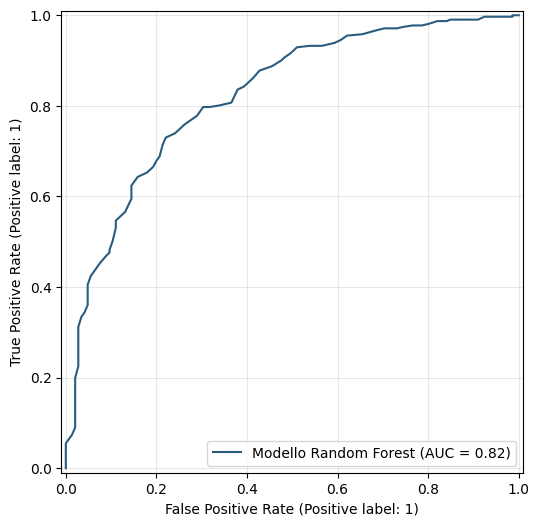

In [53]:
# 3. Grafico(By me)

fig, ax = plt.subplots(figsize=(8,6))

# Proietto il modello ROC nel grafico
RocCurveDisplay.from_estimator(
    best_rf_model,
    X_test,
    y_test,
    ax=ax,
    color = "#295C7E",
    name = 'Modello Random Forest'
)
plt.grid(True, alpha = 0.3 )


In [ ]:
# DZGROUP

In [ ]:
# REGRESSORE

 Si noti che gli iperparametri indicati potrebbero non essere quelli ottimali perché il
modello di addestri bene. Opzionalmente si discuta se non sia il caso di condizionare il
modello ad altri iperparametri e si conducano le relative prove.




TIPS PROF:
L'ANALISI delle tre task verrà effettuata separatamente, perché le feature non si sistemano con una sola analisi(possono ovviamente variare).

La GridSearch conserva lo score per ogni modello ==> quindi dagli iperparametri si deve trarre una conclusione come ad esempio se crescono, o cosa succede se su applica una configurazione differente etc..